# Previsão de Consumo de Energia Elétrica no Brasil


#### CASE TECNICO - PROJECAO DO CONSUMO DE ENERGIA ELETRICA NO BRASIL

Pipeline completo:
  1. Carga de dados (EPE - Consumo Mensal de Energia Eletrica por Classe,
     Regioes e Subsistemas, serie historica desde Jan/2004)
  2. Analise exploratoria (tendencia, sazonalidade, quebras estruturais)
  3. Modelagem 1: SARIMAX univariado (serie temporal classica) com
     regressor dummy COVID
  4. Modelagem 2: SARIMAX com regressores exogenos de submercado (SE/CO) e
     classe de consumo (Industrial), alem da dummy COVID
  5. Avaliacao (backtesting 12 meses) e projecao final para os
     proximos 12 meses (ensemble = media dos dois modelos)

Fonte oficial dos dados:
  EPE - Empresa de Pesquisa Energetica
  "Dados Abertos - Consumo Mensal de Energia Eletrica"
  https://www.epe.gov.br/pt/publicacoes-dados-abertos/dados-abertos/dados-do-consumo-mensal-de-energia-eletrica
  (botao "Dados Brutos" -> arquivo CSV/XLSX com colunas:
   Data, Regiao, Subsistema, Classe, Consumo (em MWh))
   
   

In [24]:
# Importando os pacotes

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
%matplotlib notebook

BASE_DIR = os.path.dirname(os.path.abspath(__filename__))
OUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

In [53]:
# Lendo o arquivo dos dados

arquivo_base = "data/Dados_abertos_Consumo_Mensal.xlsx"
df = pd.read_excel(arquivo_base)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            18408 non-null  int64         
 1   DataExcel       18408 non-null  datetime64[ns]
 2   Regiao          18408 non-null  object        
 3   Sistema         18408 non-null  object        
 4   Classe          18408 non-null  object        
 5   TipoConsumidor  18408 non-null  object        
 6   Consumo         18408 non-null  float64       
 7   Consumidores    18408 non-null  int64         
 8   DataVersao      18408 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 1.3+ MB


In [3]:
df

,Data,DataExcel,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao
0,20260401,2026-04-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Cativo,427903.017,495670,2026-05-28
1,20260401,2026-04-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Livre,305718.720,4176,2026-05-28
2,20260401,2026-04-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Cativo,59631.882,29064,2026-05-28
3,20260401,2026-04-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,934289.936,1497,2026-05-28
4,20260401,2026-04-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Outros,Cativo,331780.662,64390,2026-05-28
...,...,...,...,...,...,...,...,...,...
18403,20040101,2004-01-01,Sul,SUL,Industrial,Cativo,1464696.468,159190,2026-05-28
18404,20040101,2004-01-01,Sul,SUL,Industrial,Livre,346283.691,42,2026-05-28
18405,20040101,2004-01-01,Sul,SUL,Outros,Cativo,373249.407,84291,2026-05-28
18406,20040101,2004-01-01,Sul,SUL,Residencial,Cativo,1132506.000,6762504,2026-05-28


Vimos que o arquio possui 18408 linhas, todas não nulas. Agora vamos definir a coluna DataExcel como índice do dataframe, e remover as colunas Data e DataVersao, pois não serão relevantes.

In [54]:
# Limpando os dados e ordenando pela data
df.set_index('DataExcel', inplace = True)
df.drop(columns = ['Data','DataVersao'], inplace = True)
df.sort_values(by='DataExcel', inplace = True)
df.index.name = 'Data'
# Transformando de MWh para GWh
df['Consumo'] = df['Consumo'] / 1000
df

,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores
Data,,,,,,
2004-01-01,Sul,SUL,Rural,Cativo,489.375701,814350
2004-01-01,Nordeste,SISTEMAS ISOLADOS,Comercial,Cativo,0.380399,259
2004-01-01,Nordeste,NORTE INTERLIGADO,Rural,Cativo,6.727000,38269
2004-01-01,Nordeste,NORTE INTERLIGADO,Residencial,Cativo,88.588714,979289
2004-01-01,Nordeste,NORTE INTERLIGADO,Outros,Cativo,43.039900,14881
...,...,...,...,...,...,...
2026-04-01,Norte,SUDESTE / CENTRO - OESTE,Outros,Livre,2.681044,22
2026-04-01,Norte,SUDESTE / CENTRO - OESTE,Residencial,Cativo,222.219208,829523
2026-04-01,Norte,SUDESTE / CENTRO - OESTE,Rural,Cativo,36.239288,123932


Percebemos que temos uma grande amostra de dados, indo desde 2004 até abril/26, último mês com medição consolidada até o dia desta análise.

## Análise Exploratória

Periodo: 2004-01-01 a 2026-04-01
Total de observacoes mensais: 268
Consumo medio mensal: 37,759 GWh
Consumo (ultimos 12m, acumulado): 568,592 GWh
Taxa média de crescimento anual (YoY): 2.62 %


<IPython.core.display.Javascript object>


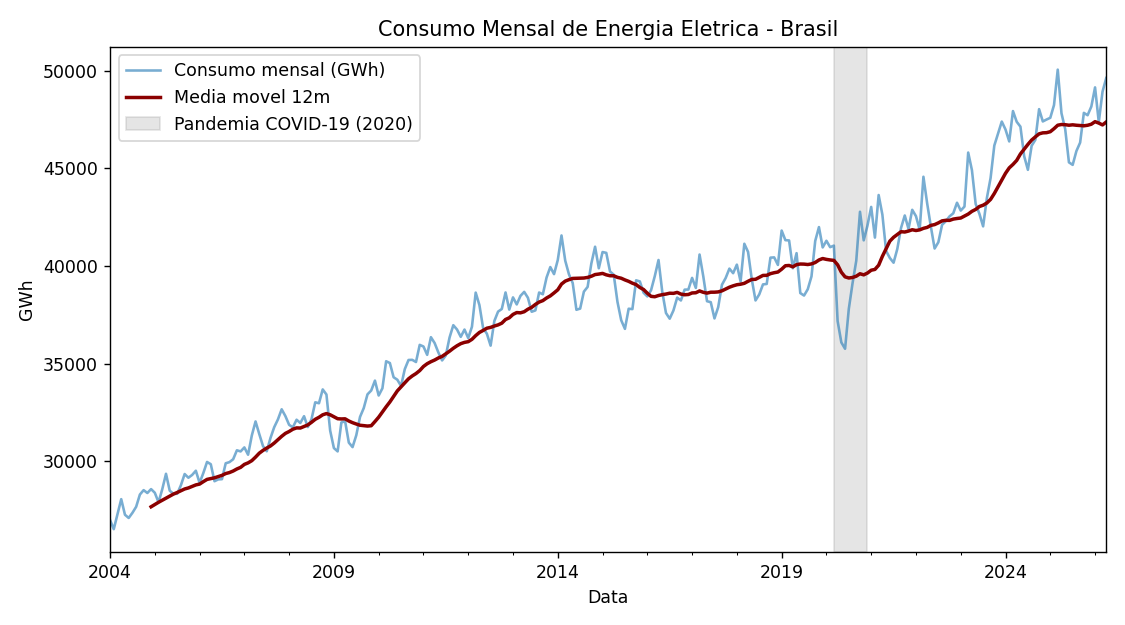

In [70]:
# Analisando a curva de consumo mensal

# Serie nacional total
nacional = df.groupby("Data")["Consumo"].sum().sort_index()
nacional.to_csv(os.path.join(OUT_DIR, "serie_nacional_mensal.csv"))

print(f"Periodo: {nacional.index.min().date()} a {nacional.index.max().date()}")
print(f"Total de observacoes mensais: {len(nacional)}")
print(f"Consumo medio mensal: {nacional.mean():,.0f} GWh")
print(f"Consumo (ultimos 12m, acumulado): {nacional.iloc[-12:].sum():,.0f} GWh")

# taxa de crescimento anual (YoY)
yoy = nacional.pct_change(12) * 100
print(f"Taxa média de crescimento anual (YoY): {yoy.mean():,.2f} %")

# --- Gráfico 1: série histórica + media móvel 12m ---

fig, ax = plt.subplots(figsize=(9, 5))
nacional.plot(ax=ax, label="Consumo mensal (GWh)", alpha=0.6)
nacional.rolling(12).mean().plot(ax=ax, label="Media movel 12m", lw=2, color="darkred")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-01"),
           color="grey", alpha=0.2, label="Pandemia COVID-19 (2020)")
ax.set_title("Consumo Mensal de Energia Eletrica - Brasil")
ax.set_ylabel("GWh")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "01_serie_historica.png"), dpi=130)
plt.show()

Percebemos uma clara tendência crescente e forte sazonalidade mensal.

<IPython.core.display.Javascript object>


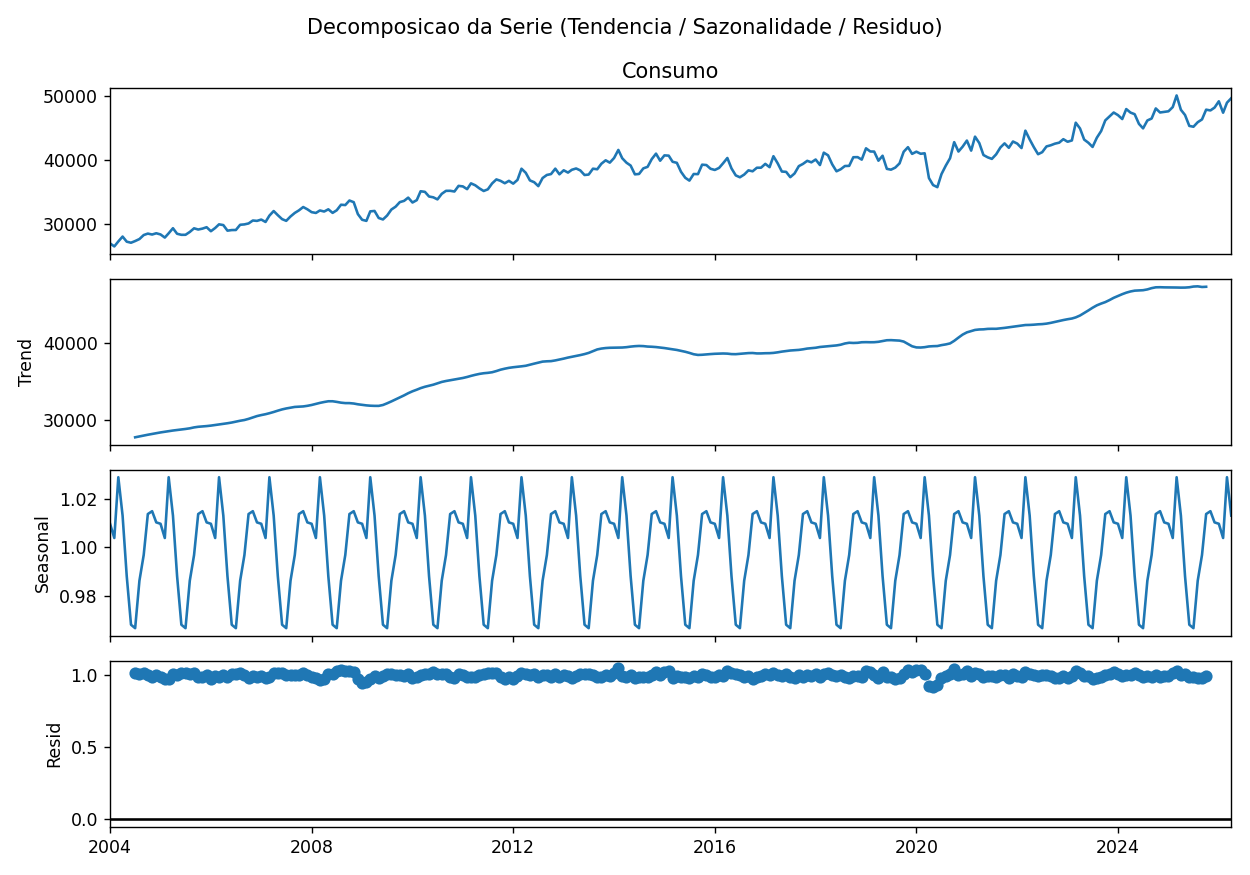

In [56]:
# --- grafico 2: decomposicao sazonal ---
decomp = seasonal_decompose(nacional, model="multiplicative", period=12)
fig = decomp.plot()
fig.set_size_inches(10, 7)
fig.suptitle("Decomposicao da Serie (Tendencia / Sazonalidade / Residuo)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "02_decomposicao.png"), dpi=130)
plt.show()

<IPython.core.display.Javascript object>


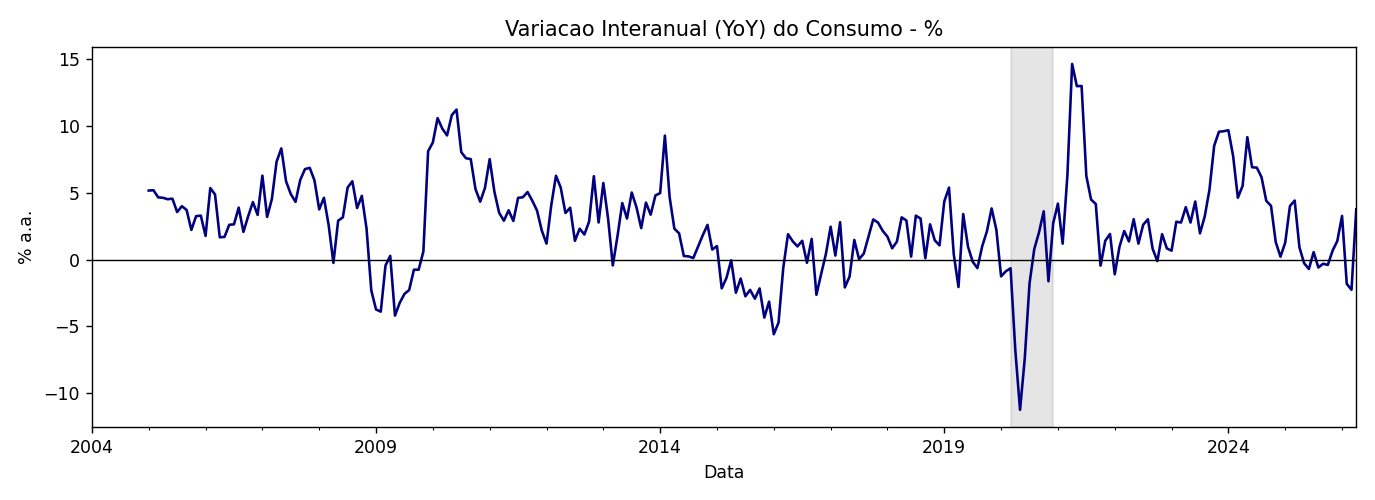

In [57]:
# --- grafico 3: crescimento YoY ---
fig, ax = plt.subplots(figsize=(11, 4))
yoy.plot(ax=ax, color="navy")
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-01"),
           color="grey", alpha=0.2)
ax.set_title("Variacao Interanual (YoY) do Consumo - %")
ax.set_ylabel("% a.a.")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "03_yoy.png"), dpi=130)
plt.show()

<IPython.core.display.Javascript object>


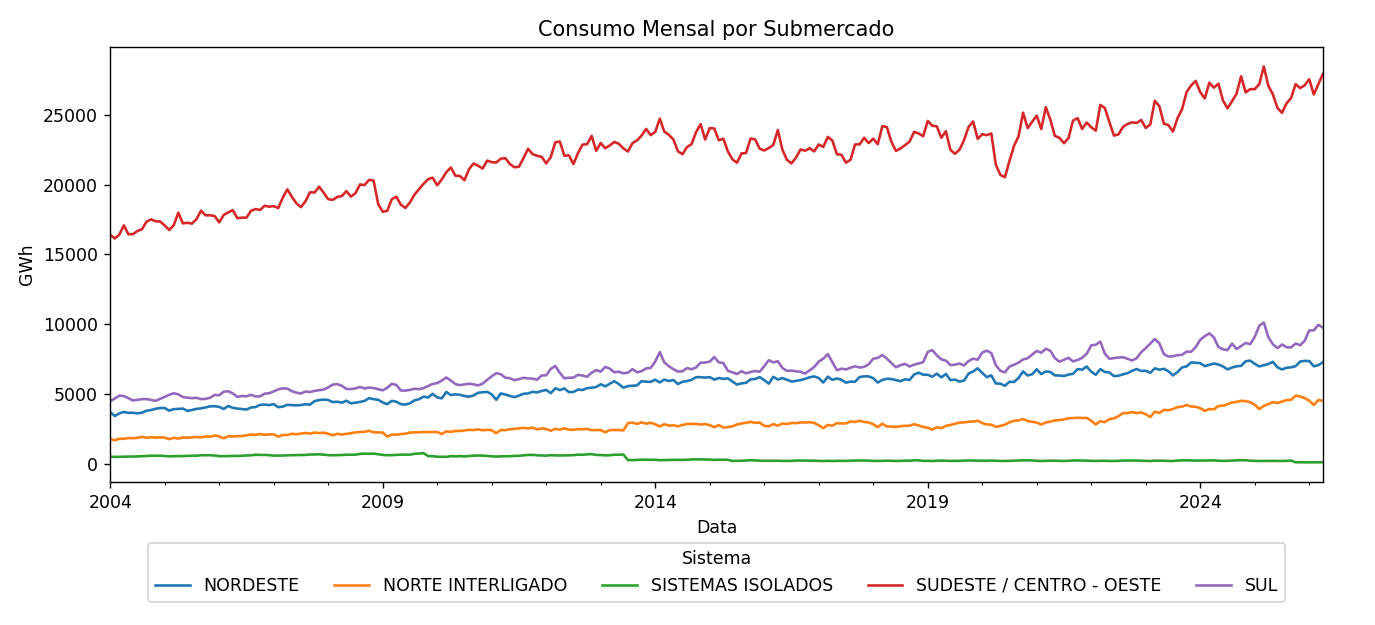

In [58]:
# --- grafico 4: consumo por submercado ---
sub_pivot = df.groupby(["Data", "Sistema"])["Consumo"].sum().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
sub_pivot.plot(ax=ax)
ax.set_title("Consumo Mensal por Submercado")
ax.set_ylabel("GWh")
ax.legend(
    title="Sistema",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5
)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "04_submercados.png"), dpi=130)
plt.show()

<IPython.core.display.Javascript object>


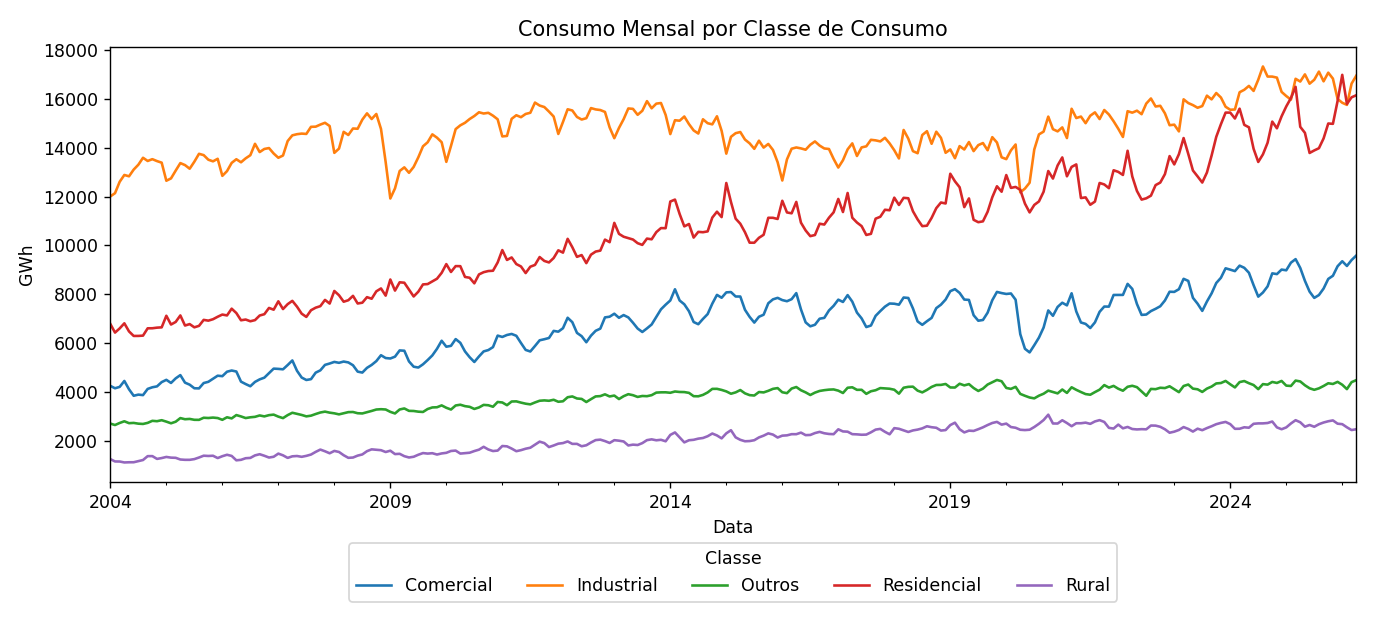

In [59]:
# --- grafico 5: consumo por classe ---
classe_pivot = df.groupby(["Data", "Classe"])["Consumo"].sum().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
classe_pivot.plot(ax=ax)
ax.set_title("Consumo Mensal por Classe de Consumo")
ax.set_ylabel("GWh")
ax.legend(
    title="Classe",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5
)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "05_classes.png"), dpi=130)
plt.show()

In [60]:
# --- quebra estrutural simples: media pre/pos COVID ---
pre = nacional[(nacional.index >= "2017-01-01") & (nacional.index < "2020-03-01")]
pos_covid = nacional[(nacional.index >= "2021-01-01") & (nacional.index < "2024-01-01")]
queda_2020 = nacional["2020-04-01":"2020-12-01"]
print("\nIndicios de quebra estrutural:")
print(f"  Media mensal 2017-2019 (pre-pandemia): {pre.mean():,.0f} GWh")
print(f"  Media mensal abr-dez/2020 (pandemia):  {queda_2020.mean():,.0f} GWh "
      f"({(queda_2020.mean()/pre.mean()-1)*100:+.1f}%)")
print(f"  Media mensal 2021-2023 (retomada):     {pos_covid.mean():,.0f} GWh "
      f"({(pos_covid.mean()/pre.mean()-1)*100:+.1f}%)")


Indicios de quebra estrutural:
  Media mensal 2017-2019 (pre-pandemia): 39,762 GWh
  Media mensal abr-dez/2020 (pandemia):  39,152 GWh (-1.5%)
  Media mensal 2021-2023 (retomada):     42,900 GWh (+7.9%)


In [75]:

# =============================================================================
# 3. MODELO 1 - SARIMAX (serie temporal classica)
# =============================================================================

def montar_exogenas(index):
    """Regressores exogenos: dummy COVID e dummy 'choque pos-covid (eletrificacao)'."""
    exog = pd.DataFrame(index=index)
    exog["covid"] = ((index >= "2020-04-01") & (index <= "2020-12-01")).astype(int)
    return exog


def modelo_sarimax(nacional, h=12, ordem=(1, 1, 1), ordem_saz=(1, 1, 1, 12)):
    print("\n================= MODELO 1: SARIMAX =================")
    exog = montar_exogenas(nacional.index)

    # ---- backtest: treino = tudo menos os ultimos 12 meses ----
    treino = nacional.iloc[:-12]
    teste = nacional.iloc[-12:]
    exog_treino = exog.iloc[:-12]
    exog_teste = exog.iloc[-12:]

    modelo_bt = SARIMAX(treino, exog=exog_treino, order=ordem,
                         seasonal_order=ordem_saz,
                         enforce_stationarity=True, enforce_invertibility=True)
    res_bt = modelo_bt.fit(disp=False)
    pred_bt = res_bt.get_forecast(steps=12, exog=exog_teste)
    yhat_bt = pred_bt.predicted_mean

    mae = mean_absolute_error(teste, yhat_bt)
    rmse = np.sqrt(mean_squared_error(teste, yhat_bt))
    mape = np.mean(np.abs((teste.values - yhat_bt.values) / teste.values)) * 100
    
    residuos = teste - yhat_bt
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Gráfico dos resíduos
    axes[0].plot(residuos)
    axes[0].axhline(0, color='red')
    axes[0].set_title('Análise dos Resíduos - Modelo 1')
    axes[0].set_xlabel('Data')
    axes[0].set_ylabel('Erro')
    
    from statsmodels.graphics.tsaplots import plot_acf
    
    # ACF dos resíduos
    plot_acf(residuos, lags=11, ax=axes[1])
    axes[1].set_title('ACF dos Resíduos - Modelo 1')

    plt.tight_layout()
    plt.show()
    
    print(f"Backtest (ultimos 12 meses observados):")
    print(f"  MAE  = {mae:,.1f} GWh")
    print(f"  RMSE = {rmse:,.1f} GWh")
    print(f"  MAPE = {mape:.2f}%")

    # ---- modelo final: treinado com toda a serie, projeta 12m futuros ----
    futuro_idx = pd.date_range(nacional.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")
    exog_futuro = montar_exogenas(futuro_idx)  # covid=0 no futuro

    modelo_final = SARIMAX(nacional, exog=exog, order=ordem, seasonal_order=ordem_saz,
                            enforce_stationarity=True, enforce_invertibility=True)
    res_final = modelo_final.fit(disp=False)
    fc = res_final.get_forecast(steps=h, exog=exog_futuro)
    proj = fc.predicted_mean
    ic = fc.conf_int(alpha=0.05)
    proj.index = futuro_idx
    ic.index = futuro_idx

    # grafico
    fig, ax = plt.subplots(figsize=(11, 5))
    nacional.iloc[-36:].plot(ax=ax, label="Historico", color="black")
    proj.plot(ax=ax, label="Projecao SARIMAX", color="tab:blue")
    ax.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color="tab:blue", alpha=0.2,
                     label="IC 95%")
    ax.set_title("Projecao SARIMAX - Consumo Nacional (proximos 12 meses)")
    ax.set_ylabel("GWh")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "06_sarimax_forecast.png"), dpi=130)
    plt.show()

    resultado = pd.DataFrame({"sarimax": proj, "sarimax_lo": ic.iloc[:, 0], "sarimax_hi": ic.iloc[:, 1]})
    return resultado, {"MAE": mae, "RMSE": rmse, "MAPE": mape}



================= MODELO 1: SARIMAX =================


<IPython.core.display.Javascript object>


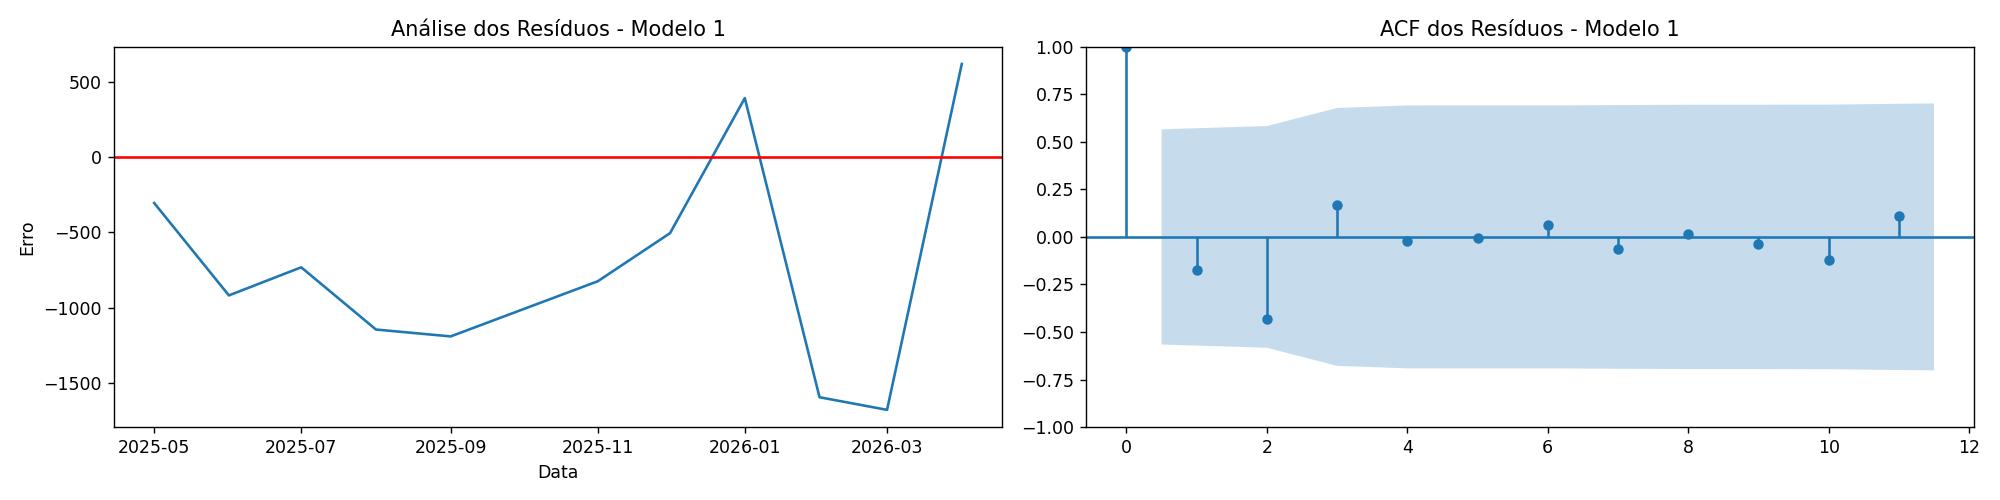

Backtest (ultimos 12 meses observados):
  MAE  = 908.3 GWh
  RMSE = 1,000.9 GWh
  MAPE = 1.92%


<IPython.core.display.Javascript object>


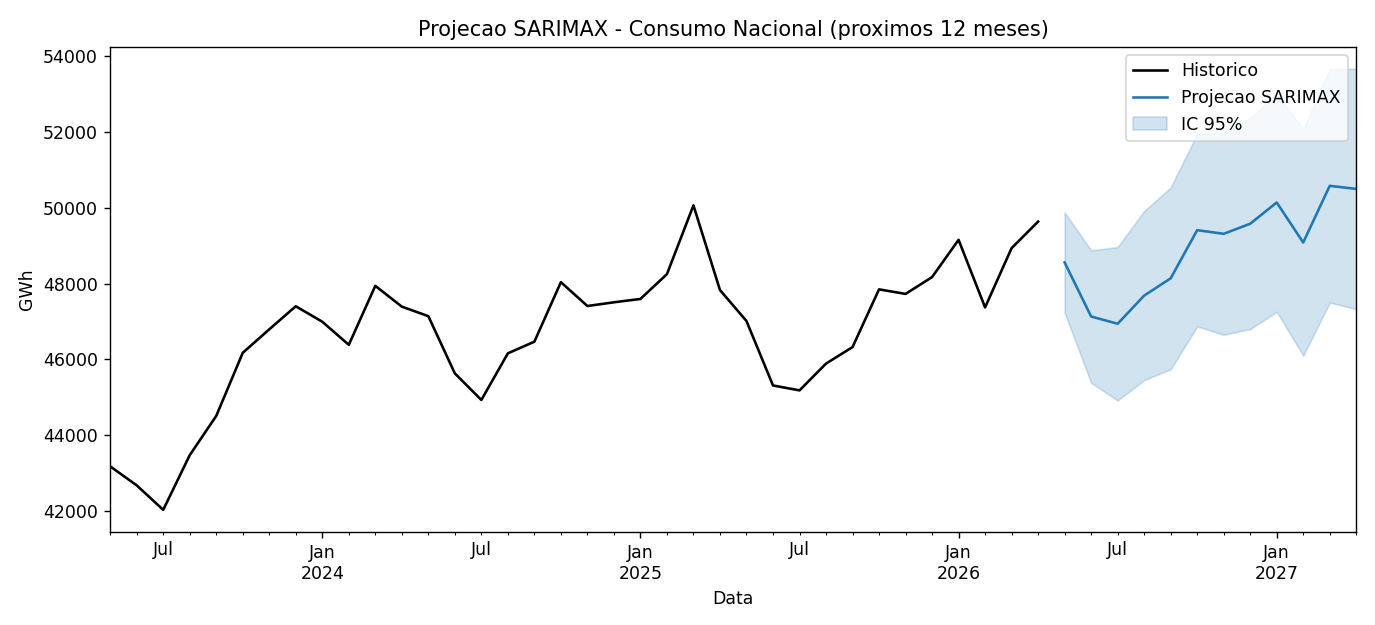

,sarimax,sarimax_lo,sarimax_hi
2026-05-01,48560.121399,47239.860081,49880.382717
2026-06-01,47133.733648,45386.729480,48880.737816
2026-07-01,46942.589665,44918.707380,48966.471950
2026-08-01,47685.160334,45454.932031,49915.388637
2026-09-01,48140.373496,45743.540527,50537.206466
2026-10-01,49411.989973,46873.179162,51950.800784
2026-11-01,49315.857607,46651.350813,51980.364401
2026-12-01,49581.546752,46802.670204,52360.423299
2027-01-01,50142.629757,47257.616051,53027.643464
2027-02-01,49086.716187,46101.789406,52071.642968


In [76]:
proj_sarimax, metricas_sarimax = modelo_sarimax(nacional)
metricas_sarimax
proj_sarimax

In [77]:
# =============================================================================
# 4. MODELO 2 - SARIMAX COM REGRESSORES EXOGENOS
#    (submercado SE/CO, classe Industrial, COVID) - alternativa ao Prophet,
#    sem dependencias de binarios compilados (Stan), 100% statsmodels.
# =============================================================================

def montar_exogenas_modelo2(df, nacional):
    """
    Regressores exogenos do Modelo 2:
      - reg_secocoshare: participacao do submercado SE/CO no consumo total
        (proxy do peso da maior regiao economica do pais)
      - reg_industrial: consumo da classe Industrial (proxy de atividade
        industrial / PIB industrial)
      - covid: dummy para o periodo de pandemia (abr-dez/2020)
    """
    sub_pivot = df.groupby(["Data", "Sistema"])["Consumo"].sum().unstack()
    classe_pivot = df.groupby(["Data", "Classe"])["Consumo"].sum().unstack()

    exog = pd.DataFrame(index=nacional.index)
    exog["reg_secocoshare"] = (sub_pivot["SUDESTE / CENTRO - OESTE"] / sub_pivot.sum(axis=1)).values
    exog["reg_industrial"] = classe_pivot["Industrial"].values
    exog["covid"] = ((exog.index >= "2020-04-01") & (exog.index <= "2020-12-01")).astype(int)
    return exog


def modelo2_sarimax_regressores(nacional, h=12, ordem=(1, 1, 1), ordem_saz=(0, 1, 1, 12)):
    """
    Modelo 2: SARIMAX com regressores exogenos (submercado e classe).
    Diferente do Modelo 1 (puramente univariado + dummy covid), aqui o
    consumo nacional eh explicado tambem pela composicao regional
    (participacao do SE/CO) e setorial (consumo Industrial), permitindo
    capturar mudancas de mix que afetam o nivel/tendencia do total nacional.
    """
    print("\n================= MODELO 2: SARIMAX COM REGRESSORES (submercado/classe) =================")
    exog = montar_exogenas_modelo2(df, nacional)

    # ---- backtest: treino = tudo menos os ultimos 12 meses ----
    treino, teste = nacional.iloc[:-12], nacional.iloc[-12:]
    exog_treino, exog_teste = exog.iloc[:-12], exog.iloc[-12:]

    modelo_bt = SARIMAX(treino, exog=exog_treino, order=ordem, seasonal_order=ordem_saz,
                         enforce_stationarity=False, enforce_invertibility=False)
    res_bt = modelo_bt.fit(disp=False)
    yhat_bt = res_bt.get_forecast(steps=12, exog=exog_teste).predicted_mean

    mae = mean_absolute_error(teste, yhat_bt)
    rmse = np.sqrt(mean_squared_error(teste, yhat_bt))
    mape = np.mean(np.abs((teste.values - yhat_bt.values) / teste.values)) * 100
    
    residuos = teste - yhat_bt
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Gráfico dos resíduos
    axes[0].plot(residuos)
    axes[0].axhline(0, color='red')
    axes[0].set_title('Análise dos Resíduos - Modelo 2')
    axes[0].set_xlabel('Data')
    axes[0].set_ylabel('Erro')
    
    from statsmodels.graphics.tsaplots import plot_acf
    
    # ACF dos resíduos
    plot_acf(residuos, lags=11, ax=axes[1])
    axes[1].set_title('ACF dos Resíduos - Modelo 2')

    plt.tight_layout()
    plt.show()
    
    print(f"Backtest (ultimos 12 meses observados):")
    print(f"  MAE  = {mae:,.1f} GWh")
    print(f"  RMSE = {rmse:,.1f} GWh")
    print(f"  MAPE = {mape:.2f}%")

    # ---- modelo final: treina com toda a serie, projeta 12m futuros ----
    futuro_idx = pd.date_range(nacional.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")

    # projeta os regressores futuros pela media sazonal historica (mesmo mes),
    # ajustada para o nivel mais recente (ultimos 12 meses observados)
    exog_futuro = pd.DataFrame(index=futuro_idx)
    for col in exog.columns:
        if col == "covid":
            exog_futuro[col] = 0
            continue
        media_mes = exog.groupby(exog.index.month)[col].mean()
        fator_nivel = exog[col].tail(12).mean() / media_mes.mean()
        exog_futuro[col] = futuro_idx.month.map(media_mes) * fator_nivel

    modelo_final = SARIMAX(nacional, exog=exog, order=ordem, seasonal_order=ordem_saz,
                            enforce_stationarity=False, enforce_invertibility=False)
    res_final = modelo_final.fit(disp=False)
    fc = res_final.get_forecast(steps=h, exog=exog_futuro)
    proj = fc.predicted_mean
    ic = fc.conf_int(alpha=0.05)
    proj.index = futuro_idx
    ic.index = futuro_idx

    resultado = pd.DataFrame({"modelo2": proj, "modelo2_lo": ic.iloc[:, 0], "modelo2_hi": ic.iloc[:, 1]})

    # grafico
    fig, ax = plt.subplots(figsize=(11, 5))
    nacional.iloc[-36:].plot(ax=ax, label="Historico", color="black")
    resultado["modelo2"].plot(ax=ax, label="Projecao Modelo 2 (SARIMAX + regressores)", color="tab:green")
    ax.fill_between(resultado.index, resultado["modelo2_lo"], resultado["modelo2_hi"],
                     color="tab:green", alpha=0.2, label="IC 95%")
    ax.set_title("Projecao Modelo 2 (SARIMAX + Submercado/Classe) - proximos 12 meses")
    ax.set_ylabel("GWh")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "07_modelo2_forecast.png"), dpi=130)
    plt.show()

    return resultado, {"MAE": mae, "RMSE": rmse, "MAPE": mape}




================= MODELO 2: SARIMAX COM REGRESSORES (submercado/classe) =================


<IPython.core.display.Javascript object>


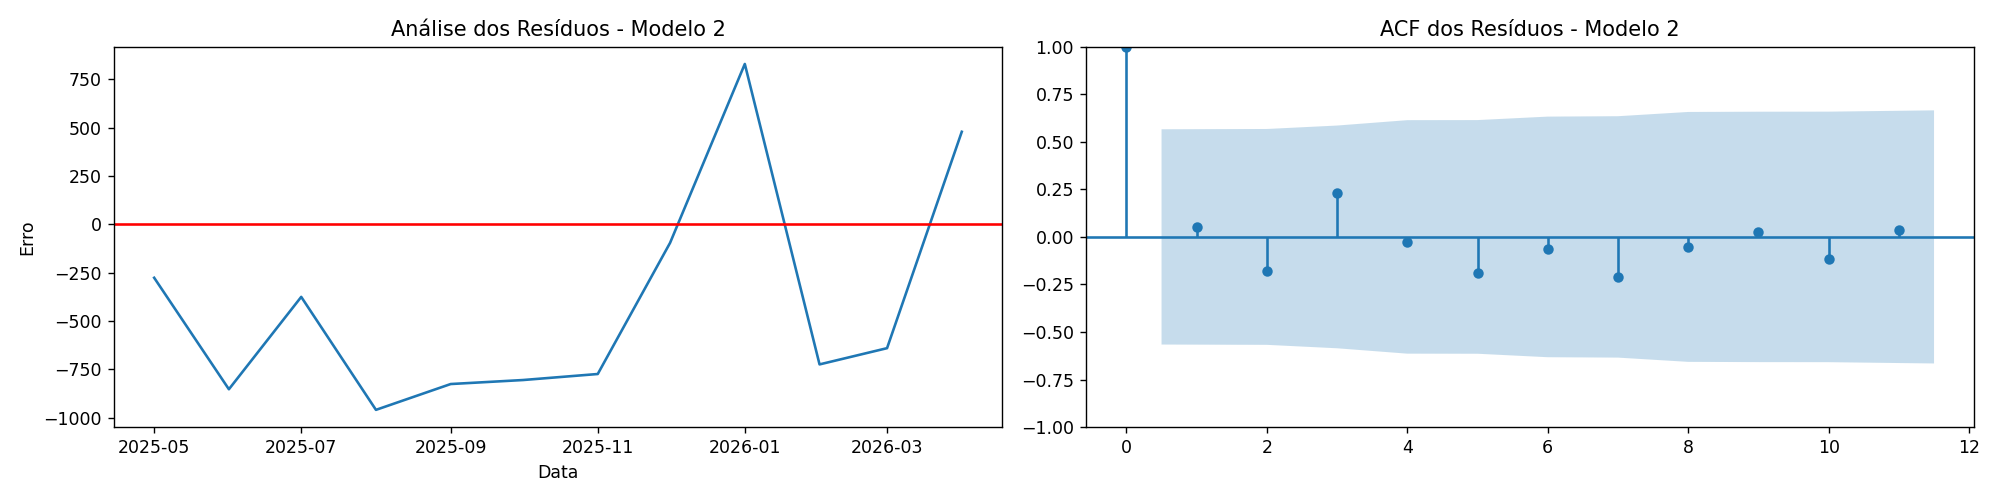

Backtest (ultimos 12 meses observados):
  MAE  = 636.4 GWh
  RMSE = 686.5 GWh
  MAPE = 1.35%


<IPython.core.display.Javascript object>


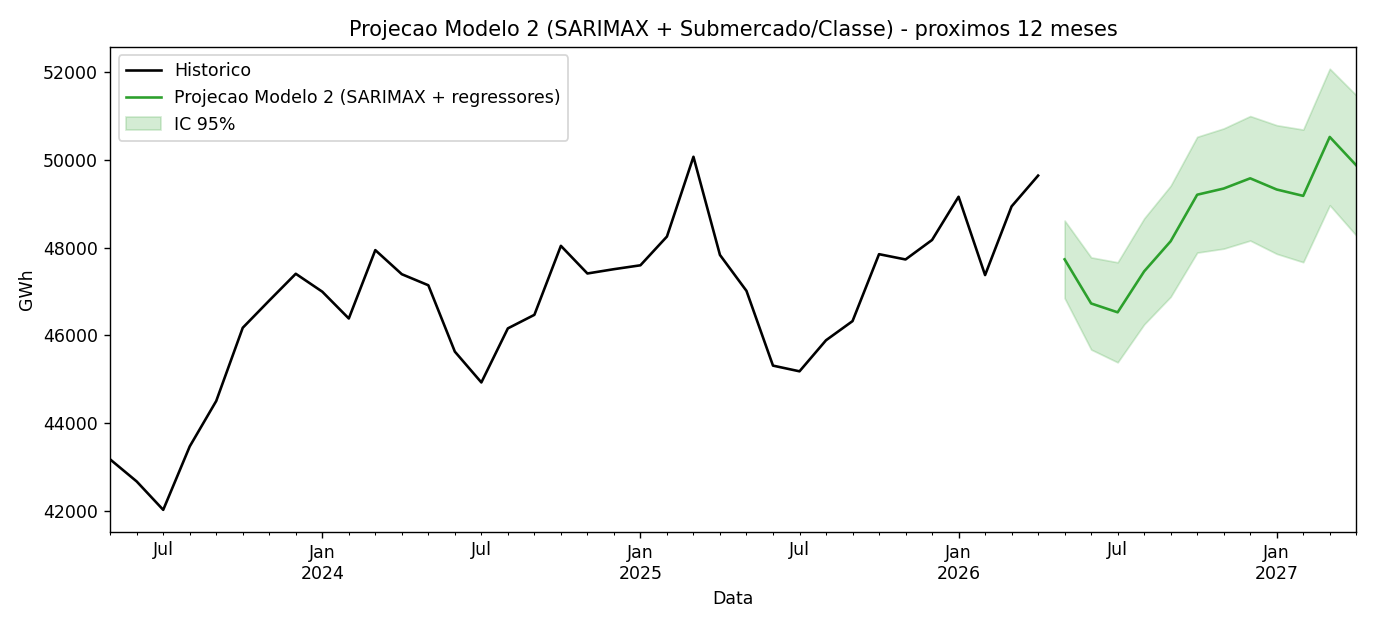

,modelo2,modelo2_lo,modelo2_hi
2026-05-01,47732.803442,46850.101966,48615.504919
2026-06-01,46728.842453,45680.592193,47777.092713
2026-07-01,46527.321856,45389.140562,47665.503151
2026-08-01,47459.141725,46253.858367,48664.425082
2026-09-01,48144.885814,46881.559419,49408.212210
2026-10-01,49203.286027,47886.439788,50520.132266
2026-11-01,49343.917879,47976.364175,50711.471584
2026-12-01,49576.431076,48160.250184,50992.611968
2027-01-01,49321.610599,47858.516519,50784.704679
2027-02-01,49176.670822,47668.158548,50685.183096


In [78]:
proj_sarimax2, metricas_sarimax2 = modelo2_sarimax_regressores(nacional)
metricas_sarimax2
proj_sarimax2

In [66]:
# =============================================================================
# 5. COMPARATIVO FINAL
# =============================================================================

def comparativo(nacional, proj_sarimax, proj_sarimax2, metricas_sarimax, metricas_sarimax2):
    print("\n================= COMPARATIVO E PROJECAO FINAL =================")
    print("Metricas de backtest (12 meses):")
    print(f"  Modelo 1 (SARIMAX univariado) -> MAE: {metricas_sarimax['MAE']:,.0f} GWh | "
          f"RMSE: {metricas_sarimax['RMSE']:,.0f} GWh | MAPE: {metricas_sarimax['MAPE']:.2f}%")
    print(f"  Modelo 2 (SARIMAX + regressores) -> MAE: {metricas_sarimax2['MAE']:,.0f} GWh | "
          f"RMSE: {metricas_sarimax2['RMSE']:,.0f} GWh | MAPE: {metricas_sarimax2['MAPE']:.2f}%")

    resultado = proj_sarimax.join(proj_sarimax2)
    resultado["media_ensemble"] = resultado[["sarimax", "modelo2"]].mean(axis=1)
    resultado.index.name = "Data"
    resultado.to_csv(os.path.join(OUT_DIR, "projecao_12m.csv"))

    fig, ax = plt.subplots(figsize=(11, 5))
    nacional.iloc[-36:].plot(ax=ax, label="Historico", color="black")
    resultado["sarimax"].plot(ax=ax, label="Modelo 1 - SARIMAX", color="tab:blue", ls="--")
    resultado["modelo2"].plot(ax=ax, label="Modelo 2 - SARIMAX + regressores", color="tab:green", ls="--")
    resultado["media_ensemble"].plot(ax=ax, label="Media (ensemble)", color="tab:red", lw=2.5)
    ax.set_title("Comparativo de Projecoes - Proximos 12 Meses")
    ax.set_ylabel("GWh")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "08_comparativo_final.png"), dpi=130)
    plt.show()

    print("\nProjecao final (GWh):")
    print(resultado.round(0))
    return resultado


================= COMPARATIVO E PROJECAO FINAL =================
Metricas de backtest (12 meses):
  Modelo 1 (SARIMAX univariado) -> MAE: 908 GWh | RMSE: 1,001 GWh | MAPE: 1.92%
  Modelo 2 (SARIMAX + regressores) -> MAE: 636 GWh | RMSE: 686 GWh | MAPE: 1.35%


<IPython.core.display.Javascript object>


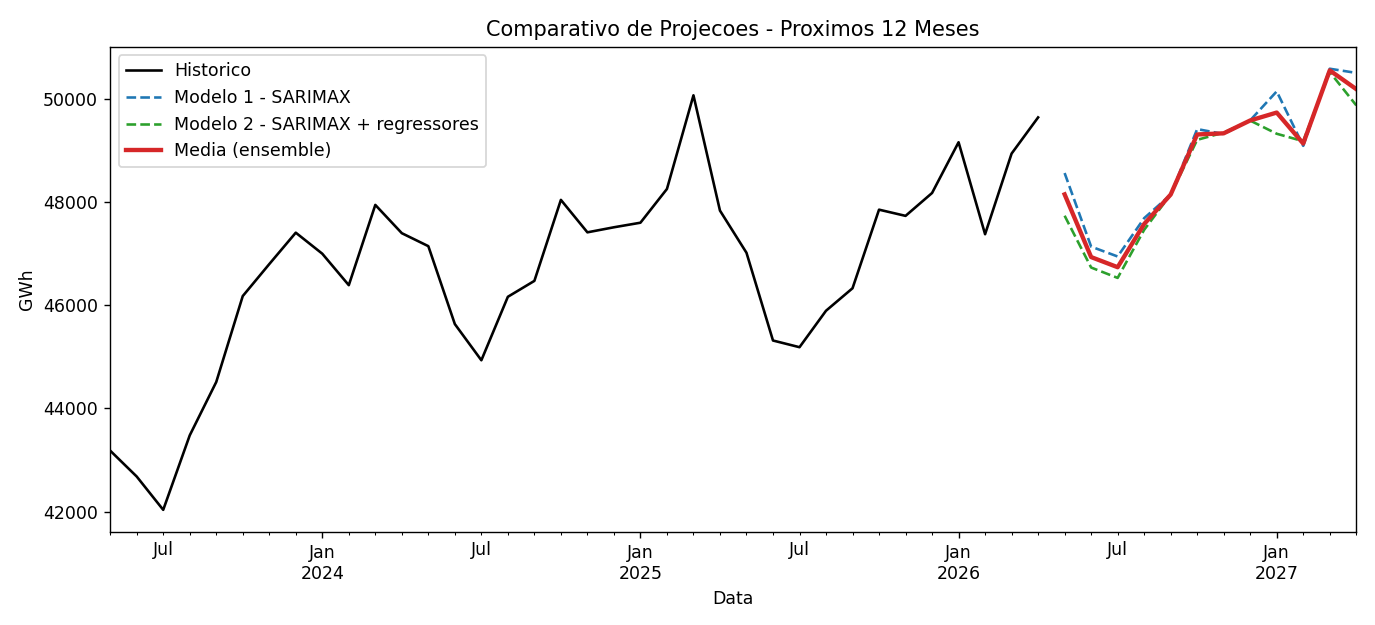


Projecao final (GWh):
            sarimax  sarimax_lo  sarimax_hi  modelo2  modelo2_lo  modelo2_hi  \
Data                                                                           
2026-05-01  48560.0     47240.0     49880.0  47733.0     46850.0     48616.0   
2026-06-01  47134.0     45387.0     48881.0  46729.0     45681.0     47777.0   
2026-07-01  46943.0     44919.0     48966.0  46527.0     45389.0     47666.0   
2026-08-01  47685.0     45455.0     49915.0  47459.0     46254.0     48664.0   
2026-09-01  48140.0     45744.0     50537.0  48145.0     46882.0     49408.0   
2026-10-01  49412.0     46873.0     51951.0  49203.0     47886.0     50520.0   
2026-11-01  49316.0     46651.0     51980.0  49344.0     47976.0     50711.0   
2026-12-01  49582.0     46803.0     52360.0  49576.0     48160.0     50993.0   
2027-01-01  50143.0     47258.0     53028.0  49322.0     47859.0     50785.0   
2027-02-01  49087.0     46102.0     52072.0  49177.0     47668.0     50685.0   
2027-03-01  50582

,sarimax,sarimax_lo,sarimax_hi,modelo2,modelo2_lo,modelo2_hi,media_ensemble
Data,,,,,,,
2026-05-01,48560.121399,47239.860081,49880.382717,47732.803442,46850.101966,48615.504919,48146.462420
2026-06-01,47133.733648,45386.729480,48880.737816,46728.842453,45680.592193,47777.092713,46931.288051
2026-07-01,46942.589665,44918.707380,48966.471950,46527.321856,45389.140562,47665.503151,46734.955761
2026-08-01,47685.160334,45454.932031,49915.388637,47459.141725,46253.858367,48664.425082,47572.151029
2026-09-01,48140.373496,45743.540527,50537.206466,48144.885814,46881.559419,49408.212210,48142.629655
2026-10-01,49411.989973,46873.179162,51950.800784,49203.286027,47886.439788,50520.132266,49307.638000
2026-11-01,49315.857607,46651.350813,51980.364401,49343.917879,47976.364175,50711.471584,49329.887743
2026-12-01,49581.546752,46802.670204,52360.423299,49576.431076,48160.250184,50992.611968,49578.988914
2027-01-01,50142.629757,47257.616051,53027.643464,49321.610599,47858.516519,50784.704679,49732.120178


In [67]:
comparativo(nacional, proj_sarimax, proj_sarimax2, metricas_sarimax, metricas_sarimax2)

Como observamos que o modelo 1 costuma exagerar na previsão do consumo (resíduos mais negativos) em comparação ao modelo 2, não faz sentido utilizarmos a média entre os dois modelos, visto que a projeção sofrerá o efeito do modelo 1 em extrapolar o volume. Dessa forma, seguiremos apenas com o modelo 2.

In [80]:
proj_sarimax2.sum()

modelo2       583604.449022
modelo2_lo    567846.487683
modelo2_hi    599362.410362
dtype: float64